<a href="https://colab.research.google.com/github/prasstyoadhi2/Clustering-ML-of-Person-of-interest-in-Epstein-Files/blob/main/Machine_Learning_clusterin_Epstein.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time # Untuk Time Taken
from google.colab import files # Untuk upload file

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =====================================================================
# TAHAP 1 & 2: DATA UNDERSTANDING & DATA PREPROCESSING
# =====================================================================
print("="*60)
print("TAHAP 1 & 2: DATA UNDERSTANDING & PREPROCESSING")
print("="*60)

print("Silakan klik 'Choose Files' untuk mengupload dataset (.xls / .xlsx / .csv):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Logika pembacaan file yang kebal "file menyamar"
try:
    df = pd.read_csv(file_name)
except Exception:
    try:
        df = pd.read_excel(file_name, engine='openpyxl')
    except Exception:
        df = pd.read_excel(file_name, engine='xlrd')

print(f"\n[INFO] Data '{file_name}' berhasil dimuat!")

# Preprocessing: Mengatasi Missing Values & Standarisasi
features = ['Flights', 'Documents', 'Connections']
df[features] = df[features].fillna(0)
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("[INFO] Preprocessing Selesai: Data telah dibersihkan dan distandarisasi.\n")

TAHAP 1 & 2: DATA UNDERSTANDING & PREPROCESSING
Silakan klik 'Choose Files' untuk mengupload dataset (.xls / .xlsx / .csv):


Saving epstein-persons-2026-02-13_cleaned(1).csv to epstein-persons-2026-02-13_cleaned(1).csv

[INFO] Data 'epstein-persons-2026-02-13_cleaned(1).csv' berhasil dimuat!
[INFO] Preprocessing Selesai: Data telah dibersihkan dan distandarisasi.



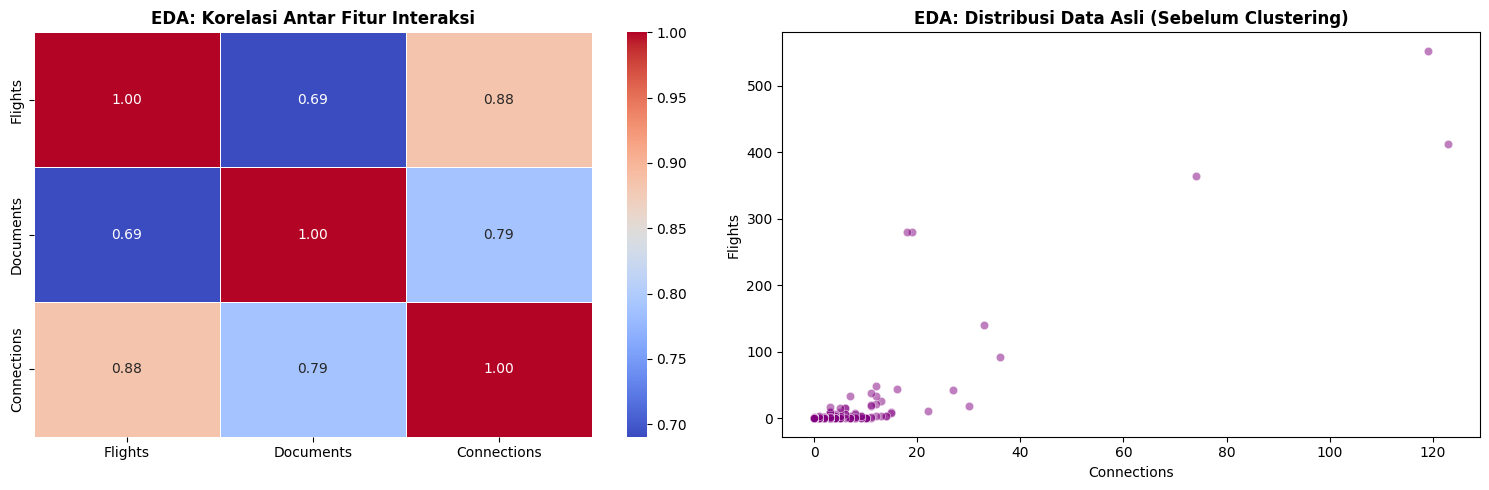

In [3]:
# =====================================================================
# TAHAP 3: EXPLORATORY DATA ANALYSIS (EDA AWAL)
# =====================================================================
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('EDA: Korelasi Antar Fitur Interaksi', weight='bold')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Connections', y='Flights', alpha=0.5, color='purple')
plt.title('EDA: Distribusi Data Asli (Sebelum Clustering)', weight='bold')
plt.tight_layout()
plt.show()

In [4]:
# =====================================================================
# TAHAP 4: DATA SPLITTING UNTUK 3 RASIO SEKALIGUS
# =====================================================================
from sklearn.model_selection import train_test_split

# Menyimpan 3 rasio ke dalam dictionary
split_ratios = [(0.1, '90:10'), (0.2, '80:20'), (0.3, '70:30')]
data_splits = {}

print("[OUTPUT TAHAP 4: HASIL PEMISAHAN DATA]")
for test_size, rasio_nama in split_ratios:
    X_train, X_test = train_test_split(X_scaled, test_size=test_size, random_state=42)

    # Menyimpan hasil split
    data_splits[rasio_nama] = {'X_train': X_train, 'X_test': X_test}

    print(f"Rasio {rasio_nama} -> Train: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris")

[OUTPUT TAHAP 4: HASIL PEMISAHAN DATA]
Rasio 90:10 -> Train: 1137 baris | Test: 127 baris
Rasio 80:20 -> Train: 1011 baris | Test: 253 baris
Rasio 70:30 -> Train: 884 baris | Test: 380 baris


In [5]:
# =====================================================================
# TAHAP 5 & 6: MODEL BUILDING & TUNING (PENGATURAN OPTIMAL)
# =====================================================================
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

k_clusters = 4
hasil_prediksi = {}

print("[OUTPUT TAHAP 5 & 6: PELATIHAN ALGORITMA]")
for rasio_nama, data in data_splits.items():
    X_train = data['X_train']

    # Mengembalikan ke parameter paling bagus (k-means++)
    kmeans = KMeans(n_clusters=k_clusters, init='k-means++', n_init=20, random_state=42)
    lbl_kmeans = kmeans.fit_predict(X_train)

    # Mengembalikan ke parameter linkage 'ward'
    agglo = AgglomerativeClustering(n_clusters=k_clusters, linkage='ward')
    lbl_agglo = agglo.fit_predict(X_train)

    # Mengembalikan ke parameter covariance 'tied'
    gmm = GaussianMixture(n_components=k_clusters, covariance_type='tied', random_state=42)
    lbl_gmm = gmm.fit_predict(X_train)

    hasil_prediksi[rasio_nama] = {
        'K-Means++': lbl_kmeans,
        'Agglomerative': lbl_agglo,
        'Gaussian Mixture (GMM)': lbl_gmm
    }
    print(f"-> Model selesai dilatih untuk data rasio {rasio_nama}!")

[OUTPUT TAHAP 5 & 6: PELATIHAN ALGORITMA]
-> Model selesai dilatih untuk data rasio 90:10!
-> Model selesai dilatih untuk data rasio 80:20!
-> Model selesai dilatih untuk data rasio 70:30!


In [11]:
# =====================================================================
# TAHAP 7: MODEL EVALUATION (SKALA DESIMAL 0.0 - 1.0)
# =====================================================================
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

df_eval_dict = {}

print("[OUTPUT TAHAP 7: EVALUASI KUALITAS CLUSTERING]")
for rasio_nama, prediksi in hasil_prediksi.items():
    X_train = data_splits[rasio_nama]['X_train']
    hasil_evaluasi = []

    for model_name, labels in prediksi.items():
        sil_score = silhouette_score(X_train, labels)
        dbi_score = davies_bouldin_score(X_train, labels)

        hasil_evaluasi.append({
            'Algoritma': model_name,
            'Silhouette Score': sil_score,
            'DBI Score': dbi_score
        })

    df_eval = pd.DataFrame(hasil_evaluasi)
    df_eval_dict[rasio_nama] = df_eval

    print(f"\n" + "="*45)
    print(f" TABEL EVALUASI: RASIO {rasio_nama}")
    print("="*45)
    display(df_eval.round(3))

[OUTPUT TAHAP 7: EVALUASI KUALITAS CLUSTERING]

 TABEL EVALUASI: RASIO 90:10


,Algoritma,Silhouette Score,DBI Score
0,K-Means++,0.976,0.320
1,Agglomerative,0.928,0.542
2,Gaussian Mixture (GMM),0.915,0.507



 TABEL EVALUASI: RASIO 80:20


,Algoritma,Silhouette Score,DBI Score
0,K-Means++,0.974,0.320
1,Agglomerative,0.926,0.540
2,Gaussian Mixture (GMM),0.978,0.252



 TABEL EVALUASI: RASIO 70:30


,Algoritma,Silhouette Score,DBI Score
0,K-Means++,0.976,0.283
1,Agglomerative,0.976,0.283
2,Gaussian Mixture (GMM),0.978,0.252


[OUTPUT TAHAP 8: VISUALISASI EVALUASI]

████████████████████████████████████████████████████████████
 GRAFIK EVALUASI UNTUK RASIO 90:10
████████████████████████████████████████████████████████████


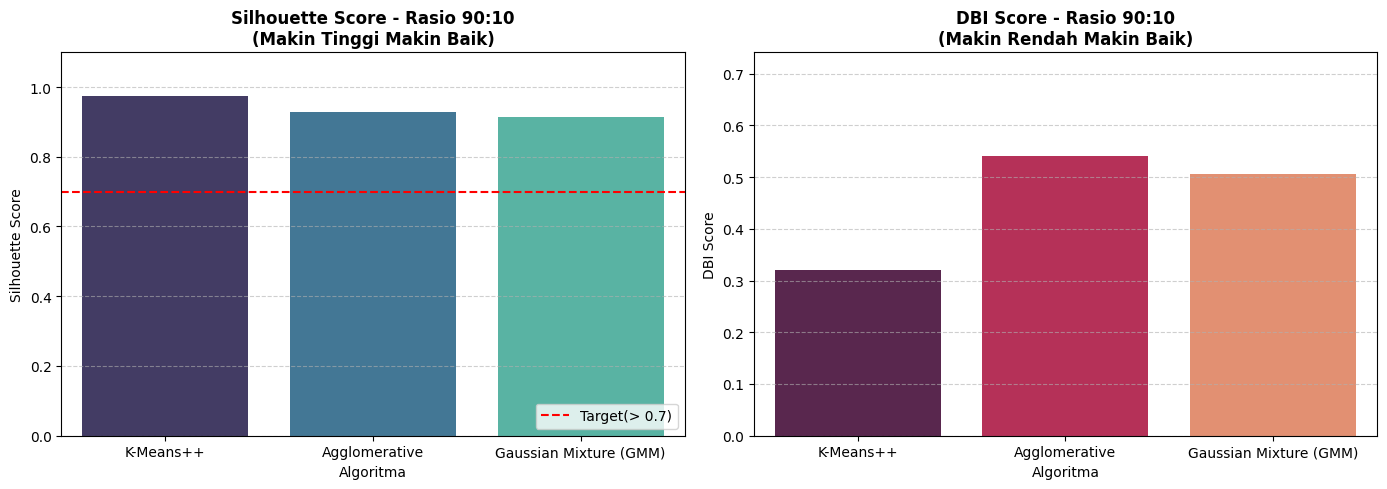


████████████████████████████████████████████████████████████
 GRAFIK EVALUASI UNTUK RASIO 80:20
████████████████████████████████████████████████████████████


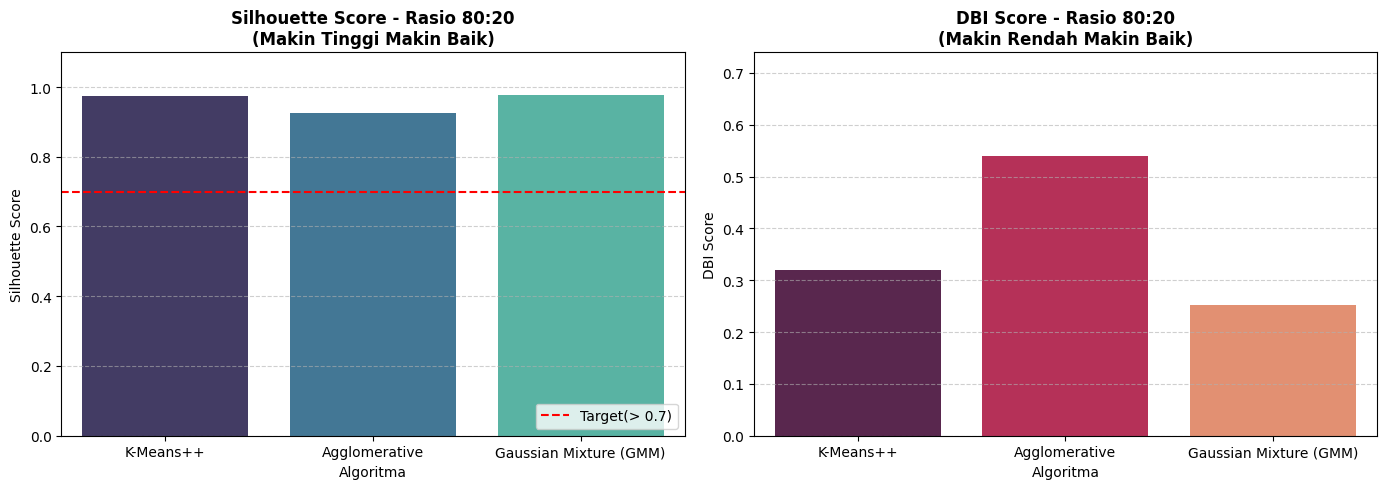


████████████████████████████████████████████████████████████
 GRAFIK EVALUASI UNTUK RASIO 70:30
████████████████████████████████████████████████████████████


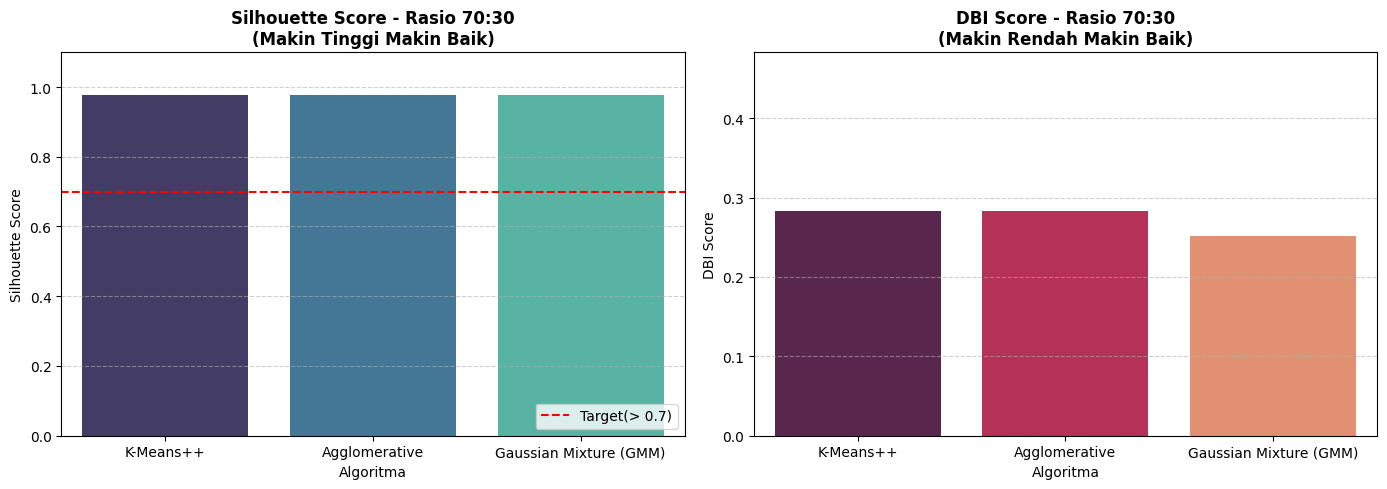

In [12]:
# =====================================================================
# TAHAP 8: MODEL COMPARISON (GRAFIK BERSEBELAHAN)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("[OUTPUT TAHAP 8: VISUALISASI EVALUASI]")
for rasio_nama, df_eval in df_eval_dict.items():
    print(f"\n" + "█"*60)
    print(f" GRAFIK EVALUASI UNTUK RASIO {rasio_nama}")
    print("█"*60)

    # Membuat 2 grafik bersebelahan (kiri-kanan)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -------------------------------------------------------------
    # Grafik 1: Silhouette Score (Skala 0.0 - 1.0)
    # -------------------------------------------------------------
    sns.barplot(data=df_eval, x='Algoritma', y='Silhouette Score', palette='mako', ax=axes[0])
    axes[0].set_title(f'Silhouette Score - Rasio {rasio_nama}\n(Makin Tinggi Makin Baik)', weight='bold')

    # Garis target Dosen 0.7
    axes[0].axhline(y=0.7, color='red', linestyle='--', label='Target(> 0.7)')
    axes[0].set_ylim(0, 1.1)
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    # -------------------------------------------------------------
    # Grafik 2: DBI Score (Asli, natural)
    # -------------------------------------------------------------
    sns.barplot(data=df_eval, x='Algoritma', y='DBI Score', palette='rocket', ax=axes[1])
    axes[1].set_title(f'DBI Score - Rasio {rasio_nama}\n(Makin Rendah Makin Baik)', weight='bold')

    # Batas atas grafik DBI disesuaikan otomatis dari angka tertinggi
    max_dbi = max(df_eval['DBI Score'])
    axes[1].set_ylim(0, max_dbi + 0.2)
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [8]:
# =====================================================================
# OUTPUT AKHIR: MODELING FINAL & PENAMAAN TIER
# =====================================================================
print("\n" + "="*80)
print("OUTPUT AKHIR: PENGELOMPOKAN FULL DATASET MENGGUNAKAN GMM")
print("="*80)

# MENGUKUR TIME TAKEN UNTUK MODELING FINAL
start_time = time.time()

best_gmm = GaussianMixture(n_components=k_clusters, covariance_type='tied', random_state=42)
df['Hasil_Cluster_Akhir'] = best_gmm.fit_predict(X_scaled)

end_time = time.time()
time_taken = end_time - start_time # Waktu eksekusi

# Penamaan Tier Dinamis (Tier 4 untuk Bos)
cluster_means = df.groupby('Hasil_Cluster_Akhir')['Flights'].mean().sort_values()
nama_kelas = {
    cluster_means.index[0]: "Tier 1 (Tamu Periferal)",
    cluster_means.index[1]: "Tier 2 (Jaringan Menengah)",
    cluster_means.index[2]: "Tier 3 (Penumpang Rutin)",
    cluster_means.index[3]: "Tier 4 (Inner Circle / Bos)"
}
df['Kategori_Tier'] = df['Hasil_Cluster_Akhir'].map(nama_kelas)

# Menampilkan Tabel Top 10
print(f"\n[TABEL] 10 Tokoh Teratas di Kelas Tertinggi (Tier 4) - Waktu Komputasi: {time_taken:.4f} detik:")
tabel_akhir = df[['Name', 'Category', 'Flights', 'Connections', 'Kategori_Tier']].sort_values(by='Flights', ascending=False)
display(tabel_akhir.head(10))


OUTPUT AKHIR: PENGELOMPOKAN FULL DATASET MENGGUNAKAN GMM

[TABEL] 10 Tokoh Teratas di Kelas Tertinggi (Tier 4) - Waktu Komputasi: 0.0139 detik:


,Name,Category,Flights,Connections,Kategori_Tier
1,Jeffrey Epstein,other,553,119,Tier 4 (Inner Circle / Bos)
0,Ghislaine Maxwell,associate,413,123,Tier 3 (Penumpang Rutin)
2,Sarah Kellen,associate,364,74,Tier 2 (Jaringan Menengah)
8,Larry Visoski,associate,281,19,Tier 2 (Jaringan Menengah)
9,Alfredo Rodriguez,associate,280,18,Tier 2 (Jaringan Menengah)
4,Nadia Marcinkova,associate,140,33,Tier 1 (Tamu Periferal)
3,Lesley Groff,associate,92,36,Tier 1 (Tamu Periferal)
19,Virginia Giuffre,other,48,12,Tier 1 (Tamu Periferal)
10,Bill Hammond,associate,44,16,Tier 1 (Tamu Periferal)
6,Adriana Ross,associate,43,27,Tier 1 (Tamu Periferal)


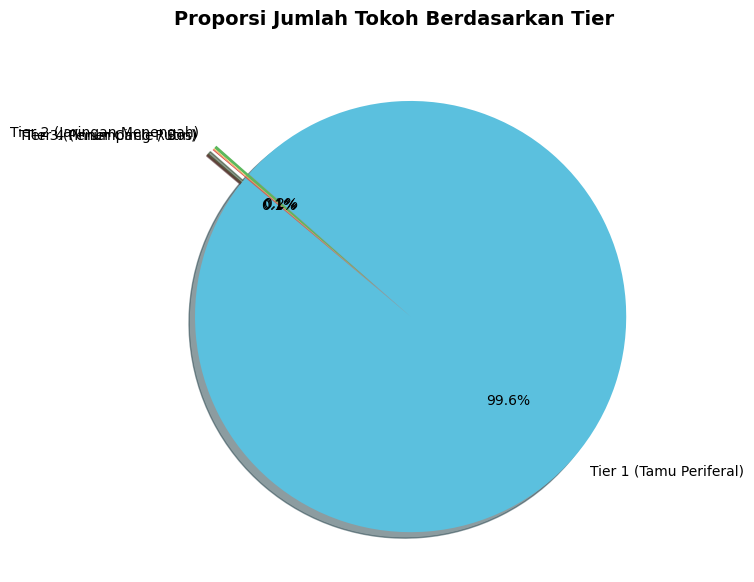

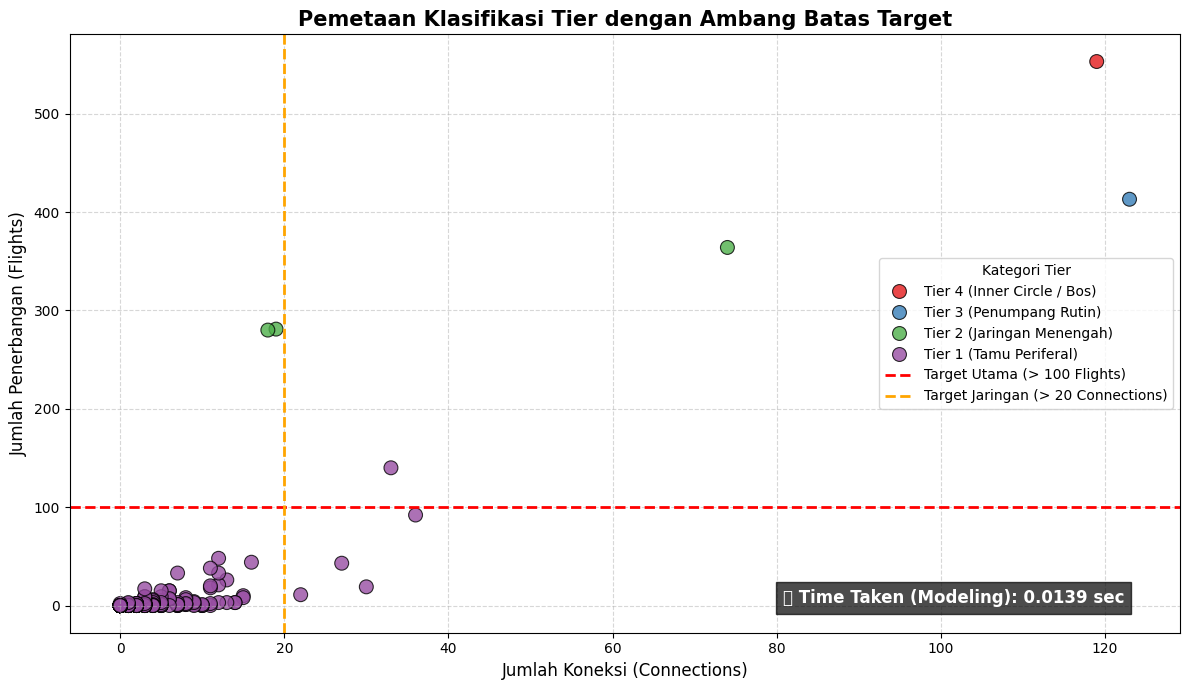

In [9]:
# =====================================================================
# ANALISIS LANJUTAN: VISUALISASI PIE, SCATTER (TARGET), & 2 ANALISIS
# =====================================================================

# 1. PIE CHART KELOMPOK TIER
plt.figure(figsize=(7, 7))
tier_counts = df['Kategori_Tier'].value_counts()
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#5bc0de', '#5cb85c', '#f0ad4e', '#d9534f'], shadow=True, explode=(0.1, 0.1, 0.1, 0.1))
plt.title('Proporsi Jumlah Tokoh Berdasarkan Tier', fontsize=14, weight='bold')
plt.show()

# 2. SCATTER PLOT EDA DENGAN TARGET & TIME TAKEN
plt.figure(figsize=(12, 7))
tier_order = ["Tier 4 (Inner Circle / Bos)", "Tier 3 (Penumpang Rutin)",
              "Tier 2 (Jaringan Menengah)", "Tier 1 (Tamu Periferal)"]

sns.scatterplot(data=df, x='Connections', y='Flights', hue='Kategori_Tier',
                hue_order=tier_order, palette='Set1', s=100, alpha=0.8, edgecolor='black')

# Garis Target Estimasi
target_flights = 100
target_connections = 20
plt.axhline(y=target_flights, color='red', linestyle='--', linewidth=2, label=f'Target Utama (> {target_flights} Flights)')
plt.axvline(x=target_connections, color='orange', linestyle='--', linewidth=2, label=f'Target Jaringan (> {target_connections} Connections)')

# Kotak Teks Time Taken
plt.text(0.95, 0.05, f"⏱️ Time Taken (Modeling): {time_taken:.4f} sec",
         transform=plt.gca().transAxes, fontsize=12, color='white',
         weight='bold', ha='right', bbox=dict(facecolor='black', alpha=0.7, pad=5))

plt.title('Pemetaan Klasifikasi Tier dengan Ambang Batas Target', fontsize=15, weight='bold')
plt.xlabel('Jumlah Koneksi (Connections)', fontsize=12)
plt.ylabel('Jumlah Penerbangan (Flights)', fontsize=12)
plt.legend(title="Kategori Tier")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

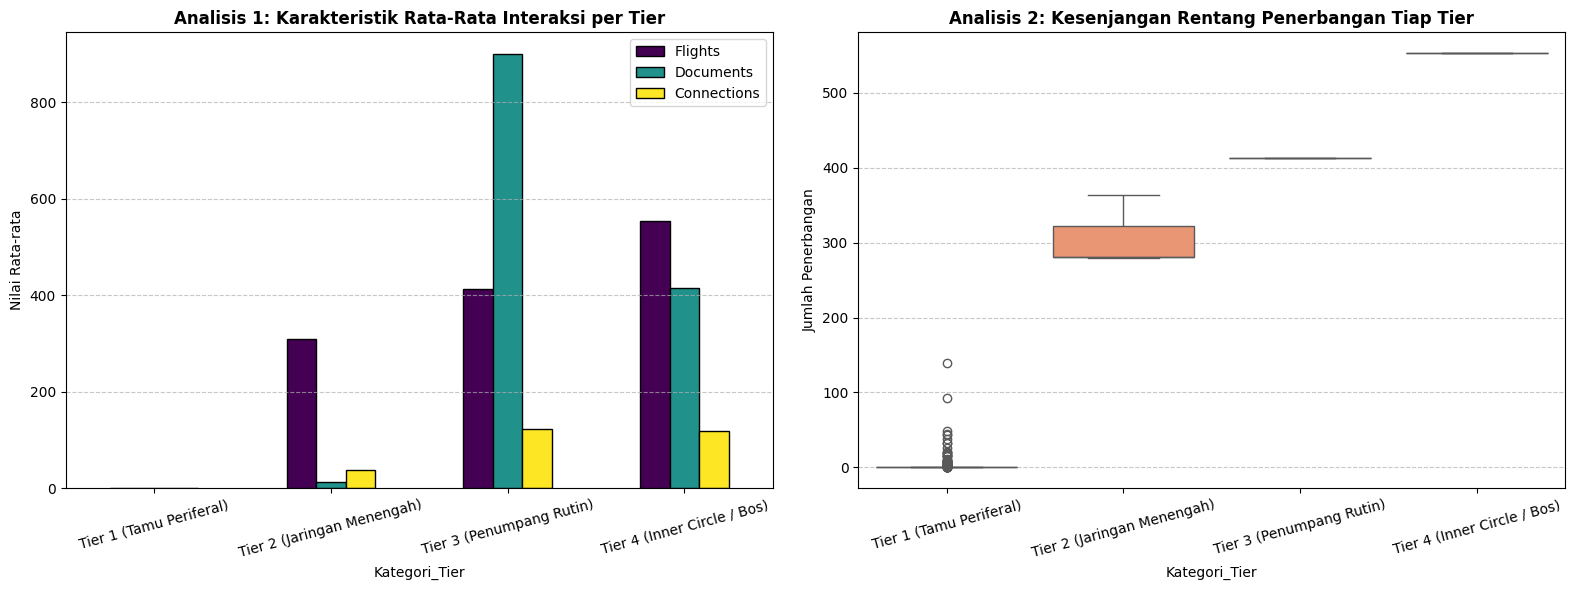

In [10]:
# 3. DUA ANALISIS TAMBAHAN (Bar Chart & Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Analisis A: Profil Karakteristik Rata-Rata
tier_profiling = df.groupby('Kategori_Tier')[features].mean()
tier_profiling.plot(kind='bar', ax=axes[0], cmap='viridis', edgecolor='black')
axes[0].set_title('Analisis 1: Karakteristik Rata-Rata Interaksi per Tier', weight='bold')
axes[0].set_ylabel('Nilai Rata-rata')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Analisis B: Kesenjangan Rentang Penerbangan
sns.boxplot(data=df, x='Kategori_Tier', y='Flights', ax=axes[1], palette='Set2', order=tier_order[::-1])
axes[1].set_title('Analisis 2: Kesenjangan Rentang Penerbangan Tiap Tier', weight='bold')
axes[1].set_ylabel('Jumlah Penerbangan')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()